# 19 — Adjoint integration: Kratos's gradients, as arrays and as data

Kratos computes exact design sensitivities, and so does this application —
by a different route. Notebook 17 drove the shipped one
(`ComputeShapeSensitivityField`) into a shape optimization. This notebook is
about the *other* side: reading **Kratos's own** adjoint stack through
`adjoint_bridge`, and then using those gradients as **training data**.

Two parts:

1. **A gradient as an array.** Kratos reports a sensitivity as a
   `{node_id: value}` dict, keyed by an *adjoint* model part whose iteration
   order need not be the primal's. Everything else in this application is a
   row-ordered array. `EvaluateResponse` converts by id — and the converted
   array is compared, node by node, against the shipped adjoint computing the
   same objective.

2. **Sobolev training.** A surrogate fitted on values alone has whatever
   derivatives the fit left behind. Grading it on the exact `dJ/dθ` as well
   makes them right — measured here on designs the model never saw.

In [1]:
import contextlib
import os
import shutil
import sys
import tempfile
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
Kratos.Logger.GetDefaultOutput().SetSeverity(Kratos.Logger.Severity.WARNING)

from KratosMultiphysics.PhysicsNeMoApplication.bridges import adjoint_bridge
from KratosMultiphysics.PhysicsNeMoApplication.bridges.mesh_bridge import deformation
from KratosMultiphysics.PhysicsNeMoApplication.physics import differentiable_residual
from KratosMultiphysics.PhysicsNeMoApplication.physics import sensitivity_utils
from KratosMultiphysics.PhysicsNeMoApplication.training import sobolev_training
from KratosMultiphysics.PhysicsNeMoApplication.training import training_utils


def FindDirectory(relative):
    """Walks up for a directory under tests/.

    A notebook has no __file__, and cwd is only the notebook's own directory
    by Jupyter convention - so the cases are found by walking up rather than
    by a fixed relative path.
    """
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "tests" / relative
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f"could not find tests/{relative} above {Path.cwd()}")


@contextlib.contextmanager
def Quiet():
    """Silences Kratos' solver chatter around a block.

    WARNING is Kratos' highest severity, so its own deprecation notices
    cannot be turned off through the logger - and because the logging happens
    in C++, contextlib.redirect_stdout never sees it. The file descriptor
    itself has to be redirected. Python exceptions are unaffected.
    """
    saved = os.dup(1)
    with open(os.devnull, "w") as null:
        os.dup2(null.fileno(), 1)
    try:
        yield
    finally:
        os.dup2(saved, 1)
        os.close(saved)


SOLVER_CASES = FindDirectory("kratos_solver_cases")
ADJOINT_CASES = FindDirectory("adjoint_cases")
sys.path.insert(0, str(SOLVER_CASES))
import thermal_case

print("solver cases: ", SOLVER_CASES)
print("adjoint cases:", ADJOINT_CASES)

 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
solver cases:  /tmp/claude-1000/-home-vicente-src-Kratos/b64f5222-475d-44c4-8fcd-1386c3c04dbc/scratchpad/nbwork_b/applications/PhysicsNeMoApplication/tests/kratos_solver_cases
adjoint cases: /tmp/claude-1000/-home-vicente-src-Kratos/b64f5222-475d-44c4-8fcd-1386c3c04dbc/scratchpad/nbwork_b/applications/PhysicsNeMoApplication/tests/adjoint_cases


## Part 1 — Kratos's adjoint, through the bridge

`adjoint_cases/` holds a small cantilever: twelve nodes, a fixed `Support`
face, a point load at the `Tip`, and a `Design` sub-model-part covering the
whole body. The objective is the tip's vertical displacement.

StructuralMechanics answers it with `AdjointFiniteDifferencing*` elements,
`ResidualBasedAdjointStaticScheme` and `SensitivityBuilder` — machinery
entirely separate from anything in this application. A Kratos response
function also runs its own primal *and* adjoint analyses and re-reads the
mdpa for a **second** model, so it only works from the case's own working
directory: the cell below copies the case somewhere temporary and moves
there.

In [2]:
RESPONSE_SETTINGS = Kratos.Parameters("""{
    "response_id"          : "tip_displacement",
    "response_application" : "structural_mechanics",
    "response_settings"    : {
        "response_type"                    : "adjoint_nodal_displacement",
        "gradient_mode"                    : "semi_analytic",
        "step_size"                        : 1e-7,
        "primal_settings"                  : "cantilever_primal.json",
        "adjoint_settings"                 : "auto",
        "primal_data_transfer_with_python" : true,
        "response_part_name"               : "Tip",
        "direction"                        : [0.0, 0.0, 1.0],
        "traced_dof"                       : "DISPLACEMENT",
        "sensitivity_settings"             : {
            "sensitivity_model_part_name"               : "Design",
            "nodal_solution_step_sensitivity_variables" : ["SHAPE_SENSITIVITY"],
            "build_mode"                                : "static"
        }
    }
}""")

TIP_NODE = 9

OBJECTIVE = Kratos.Parameters("""{
    "type"          : "traced_node",
    "variable_name" : "DISPLACEMENT",
    "node_id"       : 9,
    "direction"     : [0.0, 0.0, 1.0]
}""")


def KratosAdjoint():
    """J and dJ/dX from StructuralMechanics' own adjoint stack."""
    model = Kratos.Model()
    response = adjoint_bridge.CreateResponseFunction(RESPONSE_SETTINGS, model)
    # the primal part exists as soon as the response is constructed, and its
    # Nodes order is what defines the rows
    model_part = model["Structure"]
    with Quiet():
        fields = adjoint_bridge.EvaluateResponse(response, model_part)
    return fields


def ShippedAdjoint():
    """The same objective, through this application's own adjoint."""
    from KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_analysis import (
        StructuralMechanicsAnalysis)

    with open("cantilever_primal.json") as parameter_file:
        parameters = Kratos.Parameters(parameter_file.read())
    model = Kratos.Model()
    with Quiet():
        analysis = StructuralMechanicsAnalysis(model, parameters)
        analysis.Initialize()
        analysis.RunSolutionLoop()
    model_part = model["Structure"]

    # The boundary-condition process releases the DOFs it fixed in its
    # ExecuteFinalizeSolutionStep, and the adjoint needs the CONSTRAINED
    # operator. Skipping this gives finite sensitivities that are wrong by
    # about six orders of magnitude - the quietest trap on this page.
    for node in model_part.GetSubModelPart("Support").Nodes:
        for component in (Kratos.DISPLACEMENT_X, Kratos.DISPLACEMENT_Y,
                          Kratos.DISPLACEMENT_Z):
            node.Fix(component)

    assembler = differentiable_residual.TangentAssembler(model_part)
    dof_map = differentiable_residual.DofFieldMap(
        assembler, [("DISPLACEMENT", "node_historical")])
    weights = adjoint_bridge.MakeObjectiveWeights(OBJECTIVE, model_part)
    value = adjoint_bridge.EvaluateObjective(model_part, weights, Kratos.DISPLACEMENT)
    field = sensitivity_utils.ComputeShapeSensitivityField(
        assembler, dof_map, dof_map.FieldsToDofVector(weights), fd_step=1e-6)
    return value, field


work_dir = Path(tempfile.mkdtemp(prefix="notebook19_"))
for path in ADJOINT_CASES.iterdir():
    shutil.copy(path, work_dir / path.name)
previous_dir = Path.cwd()
os.chdir(work_dir)
try:
    kratos_fields = KratosAdjoint()
    shipped_value, shipped_field = ShippedAdjoint()
finally:
    os.chdir(previous_dir)

kratos_field = kratos_fields.nodal["SHAPE_SENSITIVITY"]
print("node ids (row order):", kratos_fields.node_ids.tolist())
print(f"J  Kratos {kratos_fields.value:+.10e}   shipped {shipped_value:+.10e}")
print(f"|dJ/dX|max = {numpy.abs(kratos_field).max():.3e}")

scale = numpy.abs(shipped_field).max()
relative = numpy.abs(kratos_field - shipped_field).max() / scale
print(f"largest disagreement: {relative:.2e} of the largest component")

# Kratos' semi_analytic gradient takes a FORWARD difference while the shipped
# field is central, so Kratos carries the larger step error and sets the bar.
assert abs(kratos_fields.value - shipped_value) < 1e-12 * abs(shipped_value)
assert relative < 1e-4, f"the two adjoints disagree by {relative:.2e}"

node ids (row order): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
J  Kratos -1.5242015408e-04   shipped -1.5242015408e-04
|dJ/dX|max = 3.137e-04
largest disagreement: 7.30e-07 of the largest component


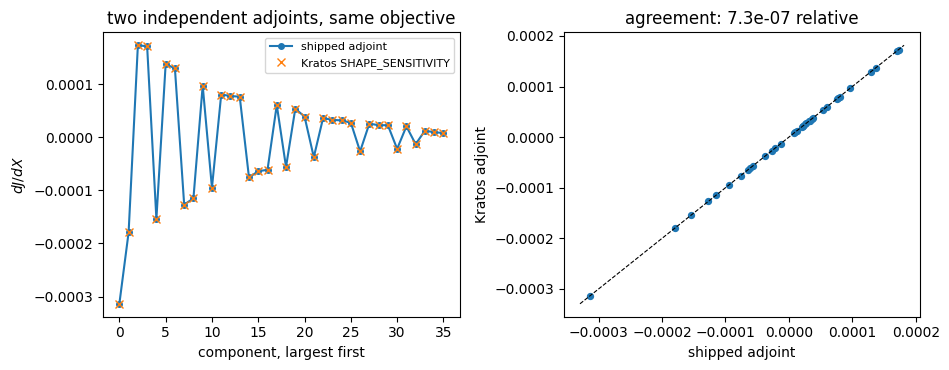

In [3]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.8))

order = numpy.argsort(-numpy.abs(shipped_field).ravel())
left.plot(shipped_field.ravel()[order], "o-", markersize=4, label="shipped adjoint")
left.plot(kratos_field.ravel()[order], "x", markersize=6,
          label="Kratos SHAPE_SENSITIVITY")
left.set_xlabel("component, largest first")
left.set_ylabel(r"$dJ/dX$")
left.set_title("two independent adjoints, same objective")
left.legend(fontsize=8)

right.scatter(shipped_field.ravel(), kratos_field.ravel(), s=18)
limits = [shipped_field.min() * 1.05, shipped_field.max() * 1.05]
right.plot(limits, limits, "k--", linewidth=0.8)
right.set_xlabel("shipped adjoint")
right.set_ylabel("Kratos adjoint")
right.set_title(f"agreement: {relative:.1e} relative")
plt.tight_layout()
plt.show()

### What the conversion is actually for

`GetNodalGradient` returns a dict, so nothing about it is ordered, and it is
keyed by the *adjoint* model part — a different `Model` entirely in
StructuralMechanics' case. `EvaluateResponse` maps ids to rows, giving the
same order `graph_bridge.NodePositions`, `DofFieldMap` and every gather in
this application use. That single conversion is what lets a Kratos gradient
sit next to a Kratos field in one training sample.

Nodes the response says nothing about keep a zero row: restricting
`sensitivity_model_part_name` to a design surface is the normal case, not an
error.

## Part 2 — training on those gradients

Now the thermal case from notebook 17: a unit square with a uniform source,
`T = 0` on the boundary, deformed by an FFD lattice with **two** design
parameters — one stretching it in `x`, one in `y`. The objective is the total
nodal temperature.

For each design we record `J` **and** `dJ/dθ`, the latter from the shipped
adjoint pushed through the deformation's chain rule
(`ComputeShapeSensitivityField` → `ComputeControlSensitivities`). That is the
gradient-augmented sample: two inputs, three targets.

In [4]:
ORIGIN = [0.0, 0.0, -0.5]
EXTENT = [1.0, 1.0, 1.0]
DIVISIONS = 6


def ControlFromTheta(theta):
    """Two design parameters into the FFD lattice's control displacements."""
    control = numpy.zeros((2, 2, 2, 3))
    control[1, :, :, 0] = theta[0]      # move the right face in x
    control[:, 1, :, 1] = theta[1]      # move the top face in y
    return control


def ThetaGradient(control_gradient):
    """dJ/dtheta from dJ/d(control): the map above is linear, so this is a sum."""
    return numpy.array([control_gradient[1, :, :, 0].sum(),
                        control_gradient[:, 1, :, 1].sum()])


def Solve(theta, reference=None):
    model = Kratos.Model()
    with Quiet():
        analysis = thermal_case.CreateThermalAnalysis(
            model, conductivity=2.0, heat_flux=1.0, divisions=DIVISIONS)
        analysis.Initialize()
    model_part = model["ThermalModelPart"]

    if reference is not None:
        points = torch.as_tensor(reference, dtype=torch.float64)
        deformed = deformation.DeformPoints(
            points, torch.as_tensor(ControlFromTheta(theta), dtype=torch.float64),
            "ffd", origin=ORIGIN, extent=EXTENT).numpy()
        for node, position in zip(model_part.Nodes, deformed):
            node.X0, node.Y0, node.Z0 = (float(position[0]), float(position[1]),
                                         float(position[2]))
            node.X, node.Y, node.Z = node.X0, node.Y0, node.Z0

    with Quiet():
        analysis.RunSolutionLoop()
    return model, model_part


def Objective(model_part):
    return sum(node.GetSolutionStepValue(Kratos.TEMPERATURE)
               for node in model_part.Nodes)


_, base_part = Solve(numpy.zeros(2))
REFERENCE = numpy.array([[n.X0, n.Y0, n.Z0] for n in base_part.Nodes])
print(f"{base_part.NumberOfNodes()} nodes, {base_part.NumberOfElements()} elements, "
      f"J(0) = {Objective(base_part):.6f}")


def Sample(theta):
    """One gradient-augmented sample: (J, dJ/dtheta) at one design."""
    _, model_part = Solve(theta, REFERENCE)
    value = Objective(model_part)

    assembler = differentiable_residual.TangentAssembler(model_part)
    dof_map = differentiable_residual.DofFieldMap(
        assembler, [("TEMPERATURE", "node_historical")])
    # J = sum of nodal temperatures, so dJ/du is all ones
    field = sensitivity_utils.ComputeShapeSensitivityField(
        assembler, dof_map, numpy.ones(dof_map.n_equations), fd_step=1e-6)
    control_gradient = sensitivity_utils.ComputeControlSensitivities(
        field, REFERENCE, ControlFromTheta(theta), "ffd",
        origin=ORIGIN, extent=EXTENT)
    return value, ThetaGradient(control_gradient)

49 nodes, 72 elements, J(0) = 0.565794


### The design being differentiated

The thermal case on its initial mesh and on an FFD-deformed design, rendered through the core pyvista bridge with the solved `TEMPERATURE`; `J` is the sum of that field.

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


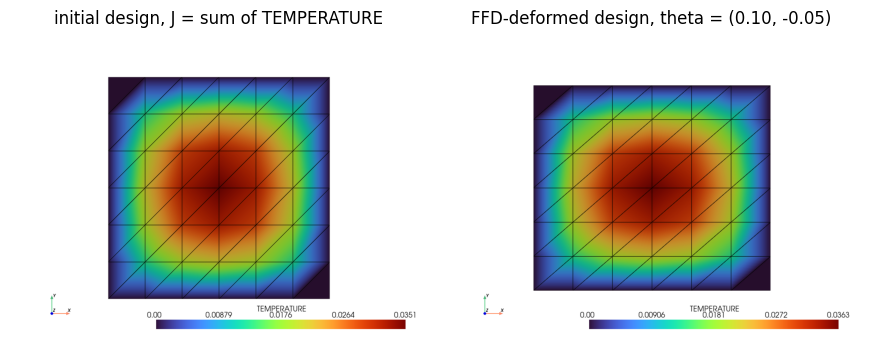

In [5]:
from KratosMultiphysics import pyvista_utilities as pv_utils

_, deformed_part = Solve(numpy.array([0.10, -0.05]), REFERENCE)
img_base = pv_utils.ScreenshotModelPart(base_part, filename=None, name=Kratos.TEMPERATURE, label="TEMPERATURE", cmap="turbo")
img_deformed = pv_utils.ScreenshotModelPart(deformed_part, filename=None, name=Kratos.TEMPERATURE, label="TEMPERATURE", cmap="turbo")
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.0))
for ax, (img, title) in zip(numpy.atleast_1d(axes), [(img_base, 'initial design, J = sum of TEMPERATURE'), (img_deformed, 'FFD-deformed design, theta = (0.10, -0.05)')]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.savefig('adjoint_designs.png', dpi=120, bbox_inches="tight"); plt.show()


In [6]:
# the gradient is exact, not merely plausible: check it against finite
# differences taken through two more full solves
probe = numpy.array([0.10, -0.05])
_, adjoint_gradient = Sample(probe)

step = 1e-5
finite_difference = []
for k in range(2):
    plus, minus = probe.copy(), probe.copy()
    plus[k] += step
    minus[k] -= step
    finite_difference.append(
        (Objective(Solve(plus, REFERENCE)[1]) - Objective(Solve(minus, REFERENCE)[1]))
        / (2.0 * step))
finite_difference = numpy.array(finite_difference)

relative = numpy.abs((adjoint_gradient - finite_difference) / finite_difference)
print(f"adjoint  dJ/dtheta = {adjoint_gradient}")
print(f"re-solve FD        = {finite_difference}")
print(f"relative           = {relative}")
assert relative.max() < 1e-6, f"chain rule disagrees with the re-solve FD: {relative}"

adjoint  dJ/dtheta = [0.44685404 0.68514197]
re-solve FD        = [0.44685404 0.68514197]
relative           = [1.43680342e-10 5.05006292e-12]


In [7]:
def BuildDataset(thetas):
    values, gradients = [], []
    for theta in thetas:
        value, gradient = Sample(theta)
        values.append(value)
        gradients.append(gradient)
    inputs = torch.tensor(numpy.asarray(thetas), dtype=torch.float64)
    targets = torch.tensor(
        numpy.column_stack([values, numpy.asarray(gradients)]), dtype=torch.float64)
    return inputs, targets


generator = numpy.random.default_rng(0)
train_thetas = generator.uniform(-0.15, 0.15, size=(16, 2))
test_thetas = generator.uniform(-0.15, 0.15, size=(24, 2))

train_inputs, train_targets = BuildDataset(train_thetas)
test_inputs, test_targets = BuildDataset(test_thetas)
print("targets are [J, dJ/dtheta_0, dJ/dtheta_1]:", list(train_targets.shape))
print("first sample:", train_targets[0].tolist())

targets are [J, dJ/dtheta_0, dJ/dtheta_1]: [16, 3]
first sample: [0.545538502833413, 0.4579531403314333, 0.6345253301617693]


### The two runs

Same architecture, same seed, same sixteen designs. The only difference is
one extra loss term.

Two settings carry the whole mechanism:

- `"target_channels" : [0]` keeps the **data** loss on the column the model
  actually predicts. Without it torch does not reject a 1-channel prediction
  against a 3-column target — it *broadcasts*, and silently trains the model
  against the mean of `J` and its two derivatives.
- `MakeSensitivityLossTerm` declares a fourth argument, so `TrainModel` hands
  it the batch targets. Three-argument terms (`physics_informed`,
  `differentiable_residual`) are called exactly as before; the arity is
  resolved once, before training starts.

`"reduction" : "relative"` divides by the reference gradient's own energy,
which is what keeps the term usable when `dJ/dθ` and `J` live on different
scales — here they differ by an order of magnitude, and on a real shape
gradient it is often several.

In [8]:
TRAINING = """{
    "epochs"          : 600,
    "batch_size"      : 8,
    "learning_rate"   : 0.01,
    "device"          : "cpu",
    "seed"            : 0,
    "target_channels" : [0]
}"""


def MakeModel(seed=1):
    torch.manual_seed(seed)
    return torch.nn.Sequential(
        torch.nn.Linear(2, 32), torch.nn.Tanh(),
        torch.nn.Linear(32, 32), torch.nn.Tanh(),
        torch.nn.Linear(32, 1)).double()


def Train(extra_loss_terms):
    model = MakeModel()
    dataset = torch.utils.data.TensorDataset(train_inputs, train_targets)
    history = training_utils.TrainModel(
        model, dataset, Kratos.Parameters(TRAINING), extra_loss_terms=extra_loss_terms)
    return model, history


def Errors(model):
    """RMSE of the value and of dJ/dtheta, on designs never trained on."""
    with torch.no_grad():
        value = float((model(test_inputs) - test_targets[:, :1]).square().mean().sqrt())
    gradient = sobolev_training.SensitivityGradient(
        model, test_inputs, coordinate_channels=2)
    return value, float((gradient - test_targets[:, 1:]).square().mean().sqrt())


sensitivity_term = sobolev_training.MakeSensitivityLossTerm(Kratos.Parameters("""{
    "coordinate_channels" : 2,
    "gradient_columns"    : [1, 2],
    "reduction"           : "relative",
    "weight"              : 1.0
}"""))

plain_model, plain_history = Train(None)
sobolev_model, sobolev_history = Train([sensitivity_term])

plain_value, plain_gradient = Errors(plain_model)
sobolev_value, sobolev_gradient = Errors(sobolev_model)

print(f"{'':10} {'value RMSE':>12} {'gradient RMSE':>15}")
print(f"{'values only':10} {plain_value:12.5f} {plain_gradient:15.5f}")
print(f"{'+ dJ/dtheta':10} {sobolev_value:12.5f} {sobolev_gradient:15.5f}")
print(f"gradient error improved {plain_gradient / sobolev_gradient:.1f}x")

# both must be real fits, or this is two failures being compared
assert plain_value < 0.05 and sobolev_value < 0.05
assert sobolev_gradient < 0.5 * plain_gradient, (
    f"gradient supervision did not help: {sobolev_gradient:.4f} vs {plain_gradient:.4f}")

             value RMSE   gradient RMSE
values only      0.01182         0.11256
+ dJ/dtheta      0.00119         0.00629
gradient error improved 17.9x


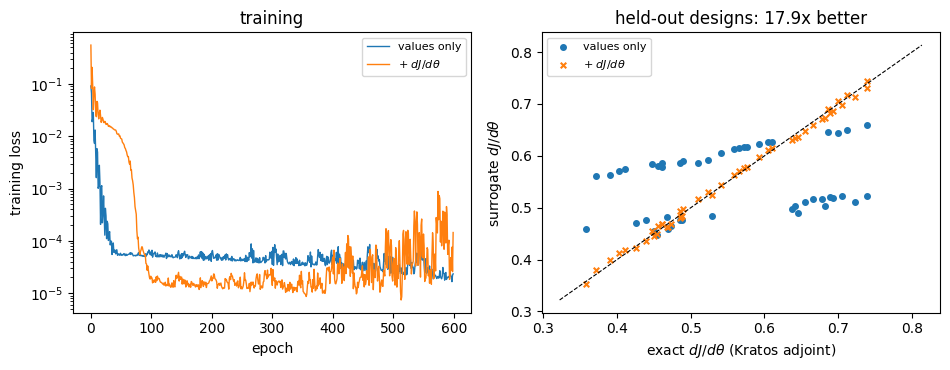

In [9]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.8))

with torch.no_grad():
    plain_prediction = plain_model(test_inputs).numpy().ravel()
    sobolev_prediction = sobolev_model(test_inputs).numpy().ravel()
plain_g = sobolev_training.SensitivityGradient(
    plain_model, test_inputs, coordinate_channels=2).detach().numpy()
sobolev_g = sobolev_training.SensitivityGradient(
    sobolev_model, test_inputs, coordinate_channels=2).detach().numpy()
reference_g = test_targets[:, 1:].numpy()

left.plot(plain_history, label="values only", linewidth=1)
left.plot(sobolev_history, label=r"+ $dJ/d\theta$", linewidth=1)
left.set_yscale("log")
left.set_xlabel("epoch")
left.set_ylabel("training loss")
left.set_title("training")
left.legend(fontsize=8)

right.scatter(reference_g.ravel(), plain_g.ravel(), s=16, label="values only")
right.scatter(reference_g.ravel(), sobolev_g.ravel(), s=16, marker="x",
              label=r"+ $dJ/d\theta$")
limits = [reference_g.min() * 0.9, reference_g.max() * 1.1]
right.plot(limits, limits, "k--", linewidth=0.8)
right.set_xlabel(r"exact $dJ/d\theta$ (Kratos adjoint)")
right.set_ylabel(r"surrogate $dJ/d\theta$")
right.set_title(f"held-out designs: {plain_gradient / sobolev_gradient:.1f}x better")
right.legend(fontsize=8)

plt.tight_layout()
plt.savefig("adjoint_sobolev.png", dpi=140)
plt.show()

## What to take away

- **The bridge is a conversion, and that is the point.** Both gradients
  already existed; what was missing was an interface. Kratos reports
  `{node_id: value}`, this application works in row-ordered arrays, and
  `EvaluateResponse` maps one to the other by id — so a gradient can sit
  beside a field in one sample.

- **Two independent adjoints agree.** The tolerance above is set by *Kratos*,
  whose `semi_analytic` gradient takes a forward difference where the shipped
  field takes a central one.

- **Gradients are free training signal you already paid for.** The adjoint
  costs one solve's worth of work per sample and is exact. Using it changes
  what the surrogate is good at: the value error improves somewhat, the
  gradient error by an order of magnitude — and a surrogate used inside an
  optimizer is read for its gradient.

- **Deploy it the other way too.** `SurrogateResponseFunction` puts a trained
  model where Kratos expects a response function, so the same model can serve
  `J` and `dJ/dX` to Kratos's own optimization tooling — the mirror of the
  co-simulation solver wrapper. See the
  [Adjoint Integration](https://kratosmultiphysics.github.io/Kratos/pages/Applications/PhysicsNeMo_Application/Adjoint/Adjoint.html)
  documentation page.